## Why Healthcare Costs Are Not Equal: The Hidden Drivers of Insurance Pricing

##### This data story analyzes how key factors such as smoking status, body mass index (BMI), and age influence health insurance costs, with the goal of addressing gaps in risk-based pricing transparency. By uncovering the primary drivers of cost variation, this analysis demonstrates how individual risk factors impact financial outcomes and highlights the importance of clearer, more accessible pricing information for consumers.

In [3]:
# Load dataset

import pandas as pd

df = pd.read_csv("insurance.csv")
df.head()



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Data Check

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


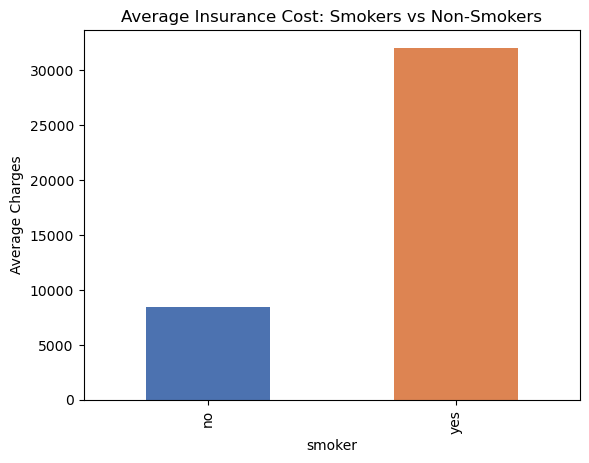

In [10]:
# Visual 1: Smoker vs Non-Smoker Costs (Bar Chart)

import matplotlib.pyplot as plt

smoker_avg = df.groupby('smoker')['charges'].mean()

plt.figure()
smoker_avg.plot(kind='bar')
plt.title('Average Insurance Cost: Smokers vs Non-Smokers')
plt.xlabel('Smoker Status')
plt.ylabel('Average Charges')
smoker_avg.plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.show()

#### This bar chart shows that indivudals who smoke were charged three times higher than non-smokers with health insurance costs.

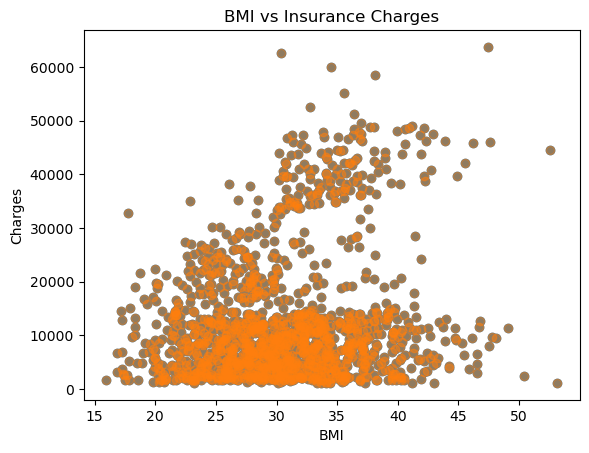

In [11]:
# Visual 2: BMI vs Charges (Scatter Plot)

plt.figure()
plt.scatter(df['bmi'], df['charges'])
plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.scatter(df['bmi'], df['charges'], alpha=0.5)
plt.show()

#### This scatterplot shows that as the BMI increases, higher charges become more common.

<Figure size 640x480 with 0 Axes>

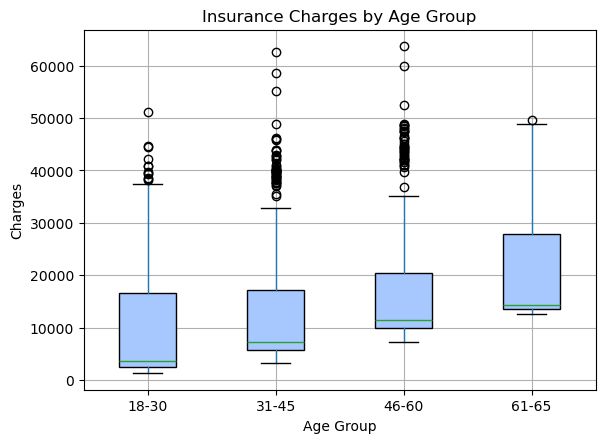

In [12]:
#Visual 3: Age vs Charges

# Create age groups
df['age_group'] = pd.cut(df['age'], bins=[18,30,45,60,65], 
                         labels=['18-30','31-45','46-60','61-65'])
# Create Box Plot
plt.figure()
df.boxplot(column='charges', by='age_group',
           patch_artist=True,
           boxprops=dict(facecolor='#A6C8FF'))
plt.title('Insurance Charges by Age Group')
plt.suptitle('')  # removes extra title
plt.xlabel('Age Group')
plt.ylabel('Charges')
plt.show()

#### This box plot indicates that insurance costs increase with age, with the older groups showing higher median charges and greater variability, though high-cost outliers exist across all age ranges.

## Conclusion: 

#### This analysis demonstrates that health insurance costs are strongly influenced by individual risk factors, particularly smoking status, BMI, and age. Smokers face significantly higher charges, while higher BMI and increasing age are also associated with rising costs. These findings highlight how personal health factors directly impact financial outcomes within the healthcare system.

#### To address this, insurance providers should improve transparency in risk-based pricing, helping individuals better understand how specific behaviors and health conditions influence their insurance costs. Greater transparency could empower individuals to make more informed lifestyle choices and promote fairness in how insurance pricing is perceived and applied.